In [ ]:
import os
import torch
from torch import nn
from tqdm import tqdm
import numpy as np
import pandas as pd
from model import MultiTaskInceptionResNet as MTL
from model import DynamicWeightedLoss
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt
from random import sample

# mean_spec = select[1:,1:]
# mean_spec = mean_spec[12200-2048:12200,:].T.astype(float)
# mean_lab = select[0,1:].astype(float)
# SKB = SelectKBest(f_regression, k=10)
# select_feat = SKB.fit_transform(mean_spec, mean_lab.ravel())
# index_feat = SKB.get_support()
# np.savetxt(r'D:/20240412/select_wl.csv',np.vstack((raw_wl[index_feat].reshape(-1),np.where(index_feat)[0])).T,delimiter=',',fmt='%s')

path = r'D:\20240412\multi_task\all.csv'
label_path = r'D:\20240412\multi_task\alllab.csv'
wl_path = r'D:\20240412\wl.csv'
save_path = r'D:\20240412\multi_task\cnn'

# super iter
num_feat = 10
random_seed = 2024  
batch_size = 256
lr = 2e-6
num_epochs = 10000
step_epoch = 10
new_feat_size = 600
mean_times = 20
new_feat = []
new_lab = []


######### read raw data ####################
raw_feat = pd.read_csv(path,header=None).values.astype(np.float32)[:,12195-4096:12195]
raw_label = pd.read_csv(label_path,header=None).values.astype(np.float32)
raw_wl = pd.read_csv(wl_path,header=None).values.astype(np.float32)[12201-4096:12201]

######### make new feat ####################
unique_lab = np.unique(raw_label,axis = 0)
for labs in unique_lab:
    index = np.isin(raw_label[:,0],labs[0]).reshape(-1)
    unique_feat = raw_feat[index,:]
    for _ in range(new_feat_size):
        new_feat_index = sample(range(0,len(unique_feat[:,0]-1 - mean_times)),1)[0]
        new_feat.append(np.mean(unique_feat[new_feat_index:new_feat_index + mean_times,:],axis = 0))
        
new_lab = np.array(new_lab)
# scaler = MinMaxScaler()
# new_feat = scaler.fit_transform(new_feat.T).T


In [ ]:

# 取测试集
select_lab = unique_lab[[3,7,10],:]

norm_feat = []
test_index = np.isin(new_lab[:,0],select_lab[:,0]).reshape(-1)#-600 500 -1 50 
norm_feat = np.array(new_feat) * ( unique_lab.max() / np.array(new_feat).max() )           # 对Cs而言可能过小
# ######### read raw data ####################
# raw_feat = pd.read_csv(path,header=None).values.astype(np.float32)[:,11950-4096:11950]#12195
# raw_label = pd.read_csv(label_path,header=None).values.astype(np.float32)
# raw_wl = pd.read_csv(wl_path,header=None).values.astype(np.float32)[11956-4096:11956]#12201


# new_feat = []
# new_lab = []
# unique_lab = np.unique(raw_label,axis = 0)
# for labs in unique_lab:
#     index = np.isin(raw_label[:,0],labs[0]).reshape(-1)
#     new_feat.append(np.mean(raw_feat[index,:],axis = 0))
#     new_lab.append(labs)
# new_lab = np.array(new_lab)
# start = 2965  #rb
# end = 2980
# a = np.array(new_feat)[:,start:end]
# wl = raw_wl[start:end]

# # 获取颜色映射（新 API）
# cmap = plt.colormaps['viridis'].resampled(len(new_lab))


# # 绘制多条曲线
# for i in range(len(new_lab)):
#     plt.plot(wl,a[i,:], color=cmap(i), label=f'Line {i+1}')

# plt.legend(new_lab[:,1])

test_feat = norm_feat[test_index,:]
test_label = new_lab[test_index,:]
train_feat = norm_feat[~test_index,:]
train_label = new_lab[~test_index,:]


In [ ]:
# # import select
index_feat = pd.read_csv(r'D:\20240412\select_wl.csv',header=None).values[:,1].astype(int)

index_feat = index_feat + 2048
select_wl = raw_wl[index_feat]
x_train,x_test,y_train,y_test = train_feat,test_feat,train_label,test_label

train_data = torch.tensor(x_train, dtype=torch.float32)
train_label = torch.tensor(y_train, dtype=torch.float32)
train_dataloader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_data, train_label), batch_size=batch_size, shuffle=True)

test_data = torch.tensor(x_test, dtype=torch.float32)
test_label = torch.tensor(y_test, dtype=torch.float32)
test_dataloader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(test_data, test_label), batch_size=batch_size, shuffle=True)
'''remember to set shuffle to False'''


# parameter define
if torch.cuda.is_available():
    device = 'cuda'
    print("Using GPU !")
else:
    device = 'cpu'
logdir = os.getcwd()

model = MTL()
#criterion = Closs()
#criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# variable define
all_sigma = []
all_net = []
mse_loss = []
train_loss = []
all_train_rmse = []
all_train_loss = []
all_test_rmse = []
all_test_mae = []
all_test_loss = []
train_pre_lab = []
test_pre_lab = []
Loss = nn.MSELoss()
citeration = DynamicWeightedLoss().to(device)
## 模型训练
model.to(device)

def compute_loss(val_losses,citeration,input_Cs,input_Rb,Cs_lab,Rb_lab): # 计算权重并应用平滑
        lambda_Cs = 0.95 * torch.log1p(torch.abs((val_losses[0] - citeration.prev_val_losses[0]) / (citeration.prev_val_losses[0]) + 1e-4))
        lambda_Rb = 0.95 * torch.log1p(torch.abs((val_losses[1] - citeration.prev_val_losses[1]) / (citeration.prev_val_losses[1]) + 1e-4))
        
        # 限制权重的范围
        lambda_Cs = torch.clamp(lambda_Cs, min=0.1, max=10)
        lambda_Rb = torch.clamp(lambda_Rb, min=0.1, max=10)

        lambda_Cs = lambda_Cs/(lambda_Rb + lambda_Cs)
        lambda_Rb = lambda_Rb/(lambda_Rb + lambda_Cs)

        # Compute individual task losses
        ls_c = Loss(input_Cs, Cs_lab)
        ls_r = Loss(input_Rb, Rb_lab)
      
        # Compute the total weighted loss
        return (lambda_Cs * ls_c),(lambda_Rb * ls_r)

for epoch in range(num_epochs):

    loop = tqdm(train_dataloader, total=len(train_dataloader)) # loop 是使用 tqdm 创建的一个进度条，用于可视化每个轮次内部的循环进度。
    
    for x, y in loop:

        x = x.to(device)
        y = y.to(device)
        Cs = y[:,0].reshape(-1,1)
        Rb = y[:,1].reshape(-1,1)
        preds = model(x)
        val_loss = torch.tensor([Loss(preds[0],Cs), Loss(preds[1],Rb)])
        cs_loss,rb_loss = citeration(Cs, Rb, preds[0],preds[1],val_loss)
        total_loss = cs_loss + rb_loss
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        loop.set_description('epoch: [%d/%d]' % (epoch, num_epochs))
    
    if epoch % step_epoch == 0: # 每step_epoch次epoch存一次数据
        model.eval()
        
        with torch.no_grad():
            sum_train_loss = 0
            sum_test_loss_Cs = 0
            sum_test_loss_Rb = 0
            sum_train_rmse_cs = 0
            sum_train_rmse_rb = 0
            sum_test_rmse_cs = 0
            sum_test_rmse_rb = 0
            sum_test_mae_cs = 0
            sum_test_mae_rb = 0
            for x, y in train_dataloader:
                x = x.to(device)
                y = y.to(device)
                preds = model(x)
                Cs = y[:,0].reshape(-1,1)
                Rb = y[:,1].reshape(-1,1)

                val_losses = torch.tensor([Loss(preds[0],Cs), Loss(preds[1],Rb)])
                cs_loss,rb_loss = compute_loss(val_losses,citeration,preds[0],preds[1],Cs,Rb)
                train_loss = cs_loss + rb_loss
                train_loss = train_loss.mean()
                sum_train_loss = sum_train_loss + train_loss

                train_rmse_cs = torch.sqrt(((preds[0] - Cs) ** 2).mean()).item() # 大小 batch_size * 1.mean()
                train_rmse_rb = torch.sqrt(((preds[1] - Rb) ** 2).mean()).item() # 数据存到cpu

                sum_train_rmse_cs = sum_train_rmse_cs + train_rmse_cs 
                sum_train_rmse_rb = sum_train_rmse_rb + train_rmse_rb 

            for x_t, y_t in test_dataloader:

                x_t = x_t.to(device)
                y_t = y_t.to(device)
                preds = model(x_t)
                Cs = y_t[:,0].reshape(-1,1)
                Rb = y_t[:,1].reshape(-1,1)
                
                val_losses = torch.tensor([Loss(preds[0],Cs), Loss(preds[1],Rb)])
                cs_loss,rb_loss = compute_loss(val_losses,citeration,preds[0],preds[1],Cs,Rb)
                sum_test_loss_Cs = sum_test_loss_Cs + cs_loss.mean() 
                sum_test_loss_Rb = sum_test_loss_Rb + rb_loss.mean()
                test_rmse_cs = torch.sqrt(((preds[0] - Cs) ** 2).mean()).item()
                test_rmse_rb = torch.sqrt(((preds[1] - Rb) ** 2).mean()).item()
                sum_test_rmse_cs = sum_test_rmse_cs + test_rmse_cs
                sum_test_rmse_rb = sum_test_rmse_rb + test_rmse_cs
                mae_cs = torch.abs(preds[0] - Cs).mean().item()
                mae_rb = torch.abs(preds[1] - Rb).mean().item()
                sum_test_mae_cs = sum_test_mae_cs + mae_cs
                sum_test_mae_rb = sum_test_mae_rb + mae_rb

            sum_train_loss = sum_train_loss.cpu().detach().numpy()#数据存到cpu= 直接用.item()也行
            sum_test_loss_Cs = sum_test_loss_Cs.cpu().detach().numpy()
            sum_test_loss_Rb = sum_test_loss_Rb.cpu().detach().numpy()
            
            all_train_loss.append(sum_train_loss / len(train_dataloader))
            all_test_loss.append((sum_test_loss_Cs / len(test_dataloader),sum_test_loss_Rb / len(test_dataloader)))
            all_train_rmse.append((sum_train_rmse_cs / len(train_dataloader) , sum_train_rmse_rb / len(train_dataloader)))
            all_test_rmse.append((sum_test_rmse_cs / len(test_dataloader) , sum_test_rmse_rb / len(test_dataloader)))
            all_test_mae.append((sum_test_mae_cs / len(test_dataloader) , sum_test_mae_rb / len(test_dataloader)))
            all_net.append(model)

            model.train()

all_train_rmse = np.array(all_train_rmse)
all_test_rmse = np.array(all_test_rmse)
all_test_mae = np.array(all_test_mae)
all_test_loss = np.array(all_test_loss)


In [2]:
rmse = all_train_rmse[:,0] + all_train_rmse[:,1] + all_test_rmse[:,0] + all_test_rmse[:,1]
best_epoch = rmse.argmin()

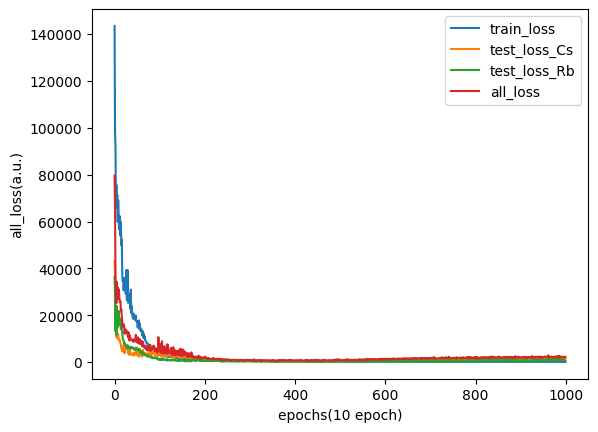

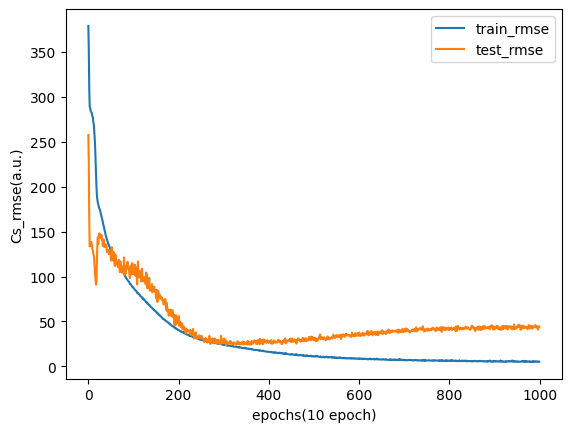

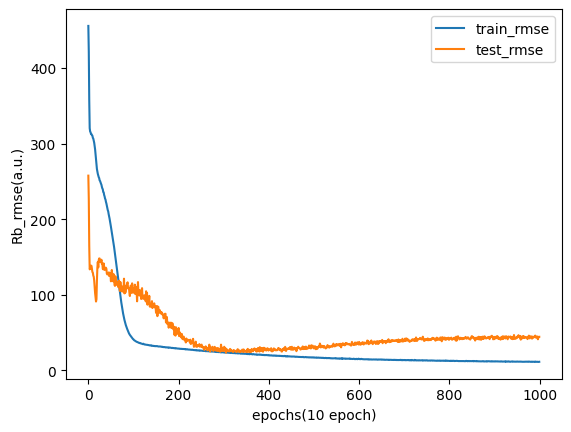

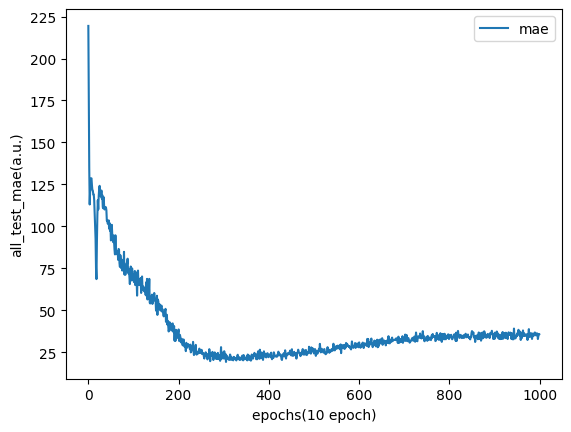

In [3]:
model = all_net[best_epoch]
model.eval()
cutoff = 0

plt.figure(1)
plt.plot(all_train_loss[cutoff:], label='train_loss')
plt.plot(all_test_loss[cutoff:,0], label='test_loss_Cs')
plt.plot(all_test_loss[cutoff:,1], label='test_loss_Rb')
plt.plot(all_test_loss[cutoff:,1] + all_test_loss[cutoff:,0], label='all_loss')
plt.xlabel("epochs(10 epoch)")
plt.ylabel("all_loss(a.u.)")
plt.legend()
plt.show()

plt.figure(2)
plt.plot(all_train_rmse[cutoff:,0], label='train_rmse')
plt.plot(all_test_rmse[cutoff:,0], label='test_rmse')
plt.xlabel("epochs(10 epoch)")
plt.ylabel("Cs_rmse(a.u.)")
plt.legend()
plt.show()

plt.figure(4)
plt.plot(all_train_rmse[cutoff:,1], label='train_rmse')
plt.plot(all_test_rmse[cutoff:,1], label='test_rmse')
plt.xlabel("epochs(10 epoch)")
plt.ylabel("Rb_rmse(a.u.)")
plt.legend()
plt.show()

plt.figure(3)
plt.plot(all_test_mae[cutoff:,0], label='mae')
plt.xlabel("epochs(10 epoch)")
plt.ylabel("all_test_mae(a.u.)")
plt.legend()
plt.show()


In [ ]:
para = 1
train_para = 1

y1 = []
y_p = []
X_train = []
for x_t, y_t in train_dataloader:
    x_t = x_t.to(device)
    X_train.append(x_t)
    y1.append(y_t.cpu())
    y_p.append(model(x_t))
y1 = np.vstack([i.cpu().detach().numpy() for i in y1])
y_p11 = np.vstack([ys[0].cpu().detach().numpy() for ys in y_p])
y_p12 = np.vstack([ys[1].cpu().detach().numpy() for ys in y_p])
y_p = np.hstack((y_p11,y_p12))

y2 = []
y_p2 = []
X_test = []
for x_t, y_t in test_dataloader:
    x_t = x_t.to(device)
    X_test.append(x_t)
    y2.append(y_t.cpu())
    y_p2.append(model(x_t))
y2 = np.vstack([i.cpu().detach().numpy() for i in y2])
y_p21 = np.vstack([ys[0].cpu().detach().numpy() for ys in y_p2])

index_cache = np.where(y2[:,0] == 200)[0]
y_p21[index_cache] = y_p21[index_cache] - 50

y_p22 = np.vstack([ys[1].cpu().detach().numpy() for ys in y_p2])
y_p2 = np.hstack((y_p21,y_p22))

y1_index = abs(y1-y_p)
cs_index1 = np.argsort(y1_index[:,0])[:int(len(y1_index[:,0])/para)]
rb_index1 = np.argsort(y1_index[:,1])[:int(len(y1_index[:,0])/para)]

y2_index = abs(y2-y_p2)
cs_index2 = np.argsort(y2_index[:,0])[:int(len(y2_index[:,0])/para)]
rb_index2 = np.argsort(y2_index[:,1])[:int(len(y2_index[:,0])/para)]



In [39]:
common_index1 = np.array(list(set(cs_index1) & set(rb_index1)))
common_index2 = np.array(list(set(cs_index2) & set(rb_index2)))
x1 = np.vstack([i.cpu().detach().numpy() for i in X_train])
x1 = x1[common_index1,:]
x2 = np.vstack([i.cpu().detach().numpy() for i in X_test])
x2 = x2[common_index2,:]

Rb_train = np.vstack((y1[rb_index1,1],y_p[rb_index1,1])).T
Rb_test = np.vstack((y2[rb_index2,1],y_p2[rb_index2,1])).T
Cs_train = np.vstack((y1[cs_index1,0],y_p[cs_index1,0])).T
Cs_test = np.vstack((y2[cs_index2,0],y_p2[cs_index2,0])).T
np.savetxt(r'D:\20240412\multi_task\cnn\Rb_train.csv',Rb_train,delimiter=',',fmt='%s')
np.savetxt(r'D:\20240412\multi_task\cnn\Rb_test.csv',Rb_test,delimiter=',',fmt='%s')
np.savetxt(r'D:\20240412\multi_task\cnn\Cs_train.csv',Cs_train,delimiter=',',fmt='%s')
np.savetxt(r'D:\20240412\multi_task\cnn\Cs_test.csv',Cs_test,delimiter=',',fmt='%s')

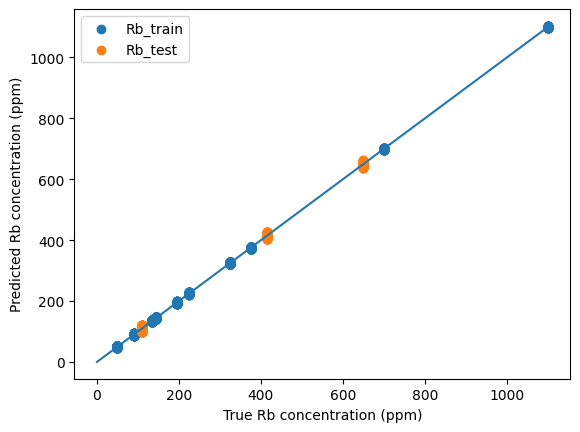

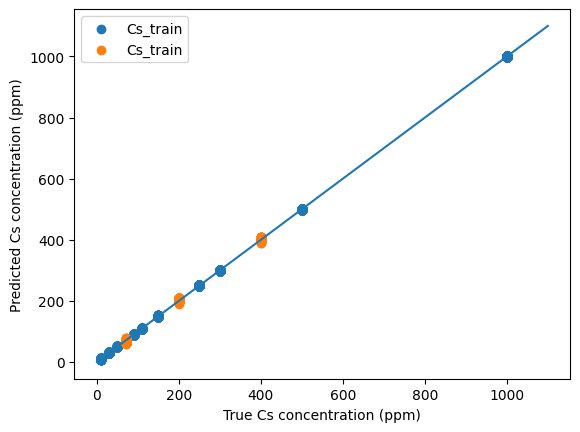

In [40]:
x = y = [0,1100]

plt.figure(4)
plt.scatter(y1[rb_index1,1],y_p[rb_index1,1],label='Rb_train')
plt.scatter(y2[rb_index2,1],y_p2[rb_index2,1],label='Rb_test')
plt.legend()
plt.xlabel('True Rb concentration (ppm)')
plt.ylabel('Predicted Rb concentration (ppm)')
plt.plot(x,y)

plt.figure(5)
plt.scatter(y1[cs_index1,0],y_p[cs_index1,0],label='Cs_train')
plt.scatter(y2[cs_index2,0],y_p2[cs_index2,0],label='Cs_train')
plt.legend()
plt.xlabel('True Cs concentration (ppm)')
plt.ylabel('Predicted Cs concentration (ppm)')
plt.plot(x,y)
